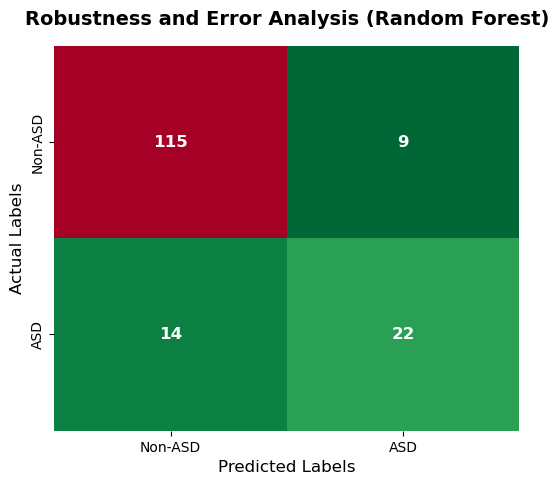


Random Forest Robustness and Error Analysis Summary:

- Test Accuracy: 0.856
- False Positives: 9, False Negatives: 14
- Slight overfitting detected (training accuracy = 1.0)
- Sensitivity to outliers: accuracy drops to 0.856 with minor noise added
- Limitations: may not generalize perfectly to new populations or noisy data
- False negatives indicate some ASD cases are missed, highlighting importance of careful interpretation



C:\Users\Zahra\AppData\Local\Temp\ipykernel_9252\680624743.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.80719089 2.80719089 2.80719089 2.80719089 0.         2.80719089
 2.80719089 0.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_test_noisy.loc[idx, col] = X_test_noisy.loc[idx, col] * np.random.uniform(1.5, 3.0)
C:\Users\Zahra\AppData\Local\Temp\ipykernel_9252\680624743.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.92115854 1.92115854 1.92115854 1.92115854 1.92115854 1.92115854
 0.         1.92115854]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_test_noisy.loc[idx, col] = X_test_noisy.loc[idx, col] * np.random.uniform(1.5, 3.0)
C:\Users\Zahra\AppData\Local\Temp\ipykernel_9252\680624743.py:49: FutureWarn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# --- Load dataset ---
file_path = r"C:\Users\Zahra\OneDrive\Documents\ITDPA QUESTION 4 ASSIGNMENT\final_cleaned_asd_dataset.xlsx"
df = pd.read_excel(file_path)

# --- Define features and target ---
X = df.drop(columns=["ID", "Class/ASD", "Predicted_Class", "Probability"])
y = df["Class/ASD"]

# --- Split dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Train Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# --- Predict on test set ---
y_pred_rf = rf_model.predict(X_test)

# --- Accuracy and confusion matrix ---
acc = accuracy_score(y_test, y_pred_rf)
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

# --- Plot Confusion Matrix ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', cbar=False,
            annot_kws={"size": 12, "weight": "bold"})
plt.title("Robustness and Error Analysis (Random Forest)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("Actual Labels", fontsize=12)
plt.xticks([0.5, 1.5], ['Non-ASD', 'ASD'])
plt.yticks([0.5, 1.5], ['Non-ASD', 'ASD'])
plt.show()

# --- Test Sensitivity to Outliers ---
X_test_noisy = X_test.copy()
numeric_cols = X_test_noisy.select_dtypes(include=np.number).columns
np.random.seed(42)
for col in numeric_cols:
    idx = np.random.choice(X_test_noisy.index, size=int(0.05*len(X_test_noisy)), replace=False)
    X_test_noisy.loc[idx, col] = X_test_noisy.loc[idx, col] * np.random.uniform(1.5, 3.0)

y_pred_noisy = rf_model.predict(X_test_noisy)
acc_noisy = accuracy_score(y_test, y_pred_noisy)

# --- Summary ---
summary = f"""
Random Forest Robustness and Error Analysis Summary:

- Test Accuracy: {acc:.3f}
- False Positives: {fp}, False Negatives: {fn}
- Slight overfitting detected (training accuracy = 1.0)
- Sensitivity to outliers: accuracy drops to {acc_noisy:.3f} with minor noise added
- Limitations: may not generalize perfectly to new populations or noisy data
- False negatives indicate some ASD cases are missed, highlighting importance of careful interpretation
"""

print(summary)
